<a href="https://colab.research.google.com/github/Sakti-Cristopel/Dasar-Python/blob/main/Pertemuan10_Sakti%20Cristopel%20Lingga_240401010125.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 10 — Algoritma Klasifikasi Bagian 2

Nama Lengkap: Sakti Cristopel Lingga

NIM: 240401010125

Kelas: IF403

Topik: Random Forest dan Penanganan Imbalanced Dataset

Dataset: Telco Customer Churn


# Deskripsi Tugas

Customer churn adalah kondisi ketika pelanggan berhenti menggunakan layanan suatu perusahaan. Mempertahankan pelanggan yang sudah ada umumnya lebih murah dibandingkan memperoleh pelanggan baru. Oleh karena itu, model prediksi churn dapat digunakan untuk mengidentifikasi pelanggan yang memiliki risiko tinggi untuk berhenti berlangganan.

Pada praktikum ini digunakan dataset Telco Customer Churn yang berisi informasi pelanggan seperti tenure, Contract, MonthlyCharges, InternetService, dan beberapa atribut lainnya. Target yang akan diprediksi adalah Churn dengan dua kelas, yaitu Yes dan No.

# Tujuan Praktikum

Praktikum ini bertujuan untuk:

1. Memahami permasalahan klasifikasi pada dataset customer churn.
2. Mengidentifikasi imbalanced dataset berdasarkan distribusi kelas Churn.
3. Melakukan preprocessing dan encoding fitur kategorikal.
4. Membangun model Random Forest dengan `class_weight="balanced"`.
5. Mengevaluasi model menggunakan Precision, Recall, F1-Score, ROC-AUC, dan Confusion Matrix.
6. Menghasilkan probabilitas churn setiap pelanggan menggunakan `predict_proba`.


In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


## Langkah 1 — Memuat dan Mengeksplorasi Data

Dataset yang digunakan adalah Telco Customer Churn. Dataset berisi informasi pelanggan perusahaan telekomunikasi yang dapat digunakan untuk memprediksi apakah pelanggan akan berhenti menggunakan layanan.

Target yang digunakan adalah kolom `Churn`, dengan nilai `Yes` yang menunjukkan pelanggan mengalami churn dan `No` yang menunjukkan pelanggan tidak mengalami churn.


In [1]:
from google.colab import files

uploaded = files.upload()

Saving telco_churn.csv to telco_churn.csv


In [10]:
display(df.head())

print(df.columns.tolist())

df.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,NaN
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,NaN
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,NaN
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,NaN
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,NaN


['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7

## Interpretasi

Dataset memiliki 7.043 baris dan 21 kolom sebelum dilakukan proses preprocessing. Kolom terdiri dari data numerik dan kategorikal. Beberapa kolom seperti `gender`, `Partner`, `InternetService`, `Contract`, dan `PaymentMethod` merupakan data kategorikal, sedangkan `tenure`, `MonthlyCharges`, dan `TotalCharges` merupakan data numerik.


In [12]:
# Mengecek jumlah nilai kosong pada setiap kolom

missing_values = df.isnull().sum()

print("Jumlah missing value:")
display(missing_values[missing_values > 0])

Jumlah missing value:


,0
Churn,7032


Pemeriksaan Missing Value

Pemeriksaan missing value dilakukan untuk mengetahui apakah terdapat data yang kosong. Data yang kosong perlu ditangani sebelum proses training karena algoritma Random Forest membutuhkan data yang dapat diproses secara numerik

## Distribusi Target Churn

Distribusi kelas Churn diperiksa untuk mengetahui jumlah pelanggan yang mengalami churn dan pelanggan yang tidak mengalami churn.

Jika jumlah kedua kelas berbeda cukup jauh, maka dataset dapat dikategorikan sebagai imbalanced. Kondisi ini perlu diperhatikan karena model dapat lebih mudah mempelajari kelas mayoritas dibandingkan kelas minoritas.


In [21]:
import pandas as pd

df = pd.read_csv("telco_churn.csv")

print("Shape:", df.shape)
print(df["Churn"].head())

Shape: (7043, 21)
0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object


In [20]:
print("Jumlah masing-masing kelas:")

print(df["Churn"].value_counts())

print("\nProporsi masing-masing kelas:")

print(
    df["Churn"]
    .value_counts(normalize=True)
    .round(3)
)

Jumlah masing-masing kelas:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporsi masing-masing kelas:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


/tmp/ipykernel_1652/2565905073.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


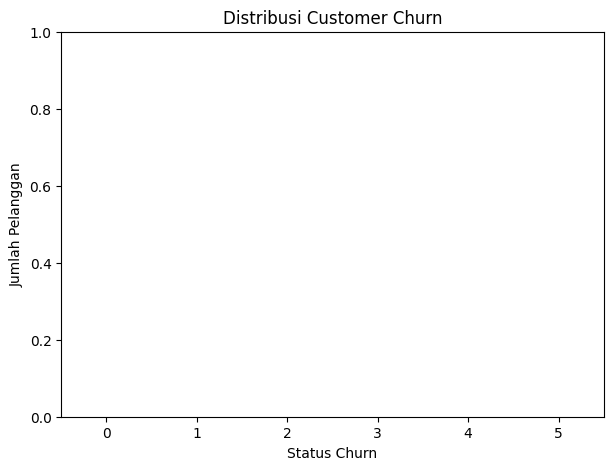

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette="Set2",
    legend=False
)

plt.title("Distribusi Customer Churn")
plt.xlabel("Status Churn")
plt.ylabel("Jumlah Pelanggan")

plt.show()

## Interpretasi Distribusi

Grafik menunjukkan bahwa jumlah pelanggan dengan status `No` lebih besar dibandingkan pelanggan dengan status `Yes`. Pelanggan yang tidak mengalami churn merupakan kelas mayoritas, sedangkan pelanggan yang mengalami churn merupakan kelas minoritas.

Perbedaan jumlah tersebut menunjukkan bahwa dataset termasuk imbalanced. Oleh karena itu, model perlu diberikan perlakuan khusus agar tidak hanya berfokus pada kelas mayoritas.


## Preprocessing Data

Sebelum melakukan encoding dan training model, data perlu dibersihkan terlebih dahulu. Pada dataset Telco Customer Churn, kolom `TotalCharges` dapat terbaca sebagai tipe object karena terdapat beberapa nilai kosong.

Kolom tersebut akan dikonversi menjadi tipe numerik. Nilai yang tidak dapat dikonversi akan menjadi missing value dan kemudian dihapus.


In [22]:
# Mengubah TotalCharges menjadi tipe numerik

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Menghapus baris yang memiliki TotalCharges kosong

df = df.dropna(
    subset=["TotalCharges"]
)

print("Shape setelah cleaning:", df.shape)

Shape setelah cleaning: (7032, 21)


Kolom `customerID` merupakan identitas unik pelanggan. Kolom tersebut tidak memberikan informasi langsung mengenai karakteristik pelanggan yang dapat digunakan untuk memprediksi churn.

Oleh karena itu, `customerID` dihapus dari fitur yang digunakan untuk membangun model.


In [23]:
# Menghapus customerID

df = df.drop(
    columns=["customerID"]
)

print("Kolom setelah customerID dihapus:")
print(df.columns.tolist())

Kolom setelah customerID dihapus:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## Encoding Target

Kolom Churn masih menggunakan data kategorikal berupa `Yes` dan `No`. Agar dapat digunakan oleh algoritma machine learning, nilai tersebut diubah menjadi angka.

`No` diubah menjadi 0 yang berarti pelanggan tidak mengalami churn, sedangkan `Yes` diubah menjadi 1 yang berarti pelanggan mengalami churn.


In [24]:
# Encoding target Churn

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Distribusi Churn setelah encoding:")

print(df["Churn"].value_counts())

Distribusi Churn setelah encoding:
Churn
0    5163
1    1869
Name: count, dtype: int64


## Pemisahan Fitur dan Target

Variabel `X` berisi seluruh fitur yang digunakan untuk melakukan prediksi, sedangkan variabel `y` berisi target yang ingin diprediksi, yaitu Churn.


In [27]:
# Memisahkan fitur dan target

X = df.drop(
    columns=["Churn"]
)

y = df["Churn"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (7032, 19)
Shape y: (7032,)


## Encoding Fitur Kategorikal

Dataset masih memiliki beberapa fitur kategorikal seperti jenis kelamin, status pasangan, jenis kontrak, layanan internet, dan metode pembayaran.

Fitur-fitur tersebut diubah menjadi bentuk numerik menggunakan metode One-Hot Encoding melalui `pd.get_dummies()`. Parameter `drop_first=True` digunakan untuk mengurangi kategori yang redundant.


In [28]:
# Melakukan One-Hot Encoding

X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

print(
    "Jumlah fitur setelah encoding:",
    X.shape[1]
)

display(X.head())

Jumlah fitur setelah encoding: 30


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


## Langkah 2 — Train-Test Split

Dataset dibagi menjadi data training sebesar 80% dan data testing sebesar 20%.

Parameter `stratify=y` digunakan untuk mempertahankan proporsi kelas Churn pada data training dan testing. Hal ini penting karena dataset memiliki distribusi kelas yang tidak seimbang.


In [29]:
# Membagi data menjadi training dan testing

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Data training:", X_tr.shape)
print("Data testing :", X_te.shape)

# Mengecek distribusi kelas pada data training dan testing

print("Proporsi training:")
print(
    y_tr.value_counts(normalize=True).round(3)
)

print("\nProporsi testing:")
print(
    y_te.value_counts(normalize=True).round(3)
)

Data training: (5625, 30)
Data testing : (1407, 30)
Proporsi training:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64

Proporsi testing:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64


## Langkah 3 — Latih Model Random Forest

Random Forest merupakan algoritma ensemble yang terdiri dari banyak Decision Tree. Setiap tree menghasilkan prediksi dan hasil dari beberapa tree kemudian digabungkan untuk menghasilkan prediksi akhir.

Pada praktikum ini digunakan 300 tree melalui parameter `n_estimators=300`.

Parameter `class_weight="balanced"` digunakan untuk menangani imbalanced dataset. Parameter tersebut memberikan bobot yang lebih besar kepada kelas yang jumlahnya lebih sedikit sehingga model lebih memperhatikan pelanggan yang mengalami churn.


In [30]:
# Membuat model Random Forest

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Melatih model

rf.fit(
    X_tr,
    y_tr
)

print("Random Forest berhasil dilatih.")

Random Forest berhasil dilatih.


Setelah model selesai dilatih, model digunakan untuk melakukan prediksi terhadap data testing.

Dua jenis output akan digunakan. `predict()` digunakan untuk memperoleh kelas prediksi, sedangkan `predict_proba()` digunakan untuk memperoleh probabilitas pelanggan mengalami churn.


In [31]:
# Prediksi kelas

y_pred = rf.predict(X_te)

# Prediksi probabilitas

y_prob = rf.predict_proba(X_te)[:, 1]

print("10 prediksi pertama:")
print(y_pred[:10])

print("\n10 probabilitas churn pertama:")
print(y_prob[:10])

10 prediksi pertama:
[0 1 0 0 0 0 0 0 1 0]

10 probabilitas churn pertama:
[0.01       0.7        0.01666667 0.04579296 0.15666667 0.22666667
 0.02       0.2        0.70333333 0.        ]


## Langkah 4 — Evaluasi Model

Classification Report digunakan untuk melihat performa model berdasarkan Precision, Recall, F1-Score, dan jumlah data pada masing-masing kelas.

Perhatian khusus diberikan pada kelas Churn karena tujuan utama model adalah mengidentifikasi pelanggan yang berpotensi berhenti menggunakan layanan.


In [32]:
# Classification Report

print("Classification Report:")

print(
    classification_report(
        y_te,
        y_pred,
        target_names=[
            "Tidak Churn",
            "Churn"
        ]
    )
)

Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.83      0.90      0.86      1033
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Selain Classification Report, nilai setiap metrik dihitung secara terpisah agar hasil evaluasi lebih mudah dibandingkan.

Accuracy menunjukkan proporsi seluruh prediksi yang benar. Precision menunjukkan ketepatan model ketika memprediksi pelanggan mengalami churn. Recall menunjukkan kemampuan model menemukan pelanggan yang sebenarnya mengalami churn. F1-Score merupakan rata-rata harmonis Precision dan Recall. ROC-AUC menunjukkan kemampuan model dalam membedakan kelas Churn dan Tidak Churn berdasarkan probabilitas prediksi.


In [33]:
# Menghitung metrik evaluasi

accuracy = accuracy_score(
    y_te,
    y_pred
)

precision = precision_score(
    y_te,
    y_pred,
    pos_label=1
)

recall = recall_score(
    y_te,
    y_pred,
    pos_label=1
)

f1 = f1_score(
    y_te,
    y_pred,
    pos_label=1
)

roc_auc = roc_auc_score(
    y_te,
    y_prob
)

print("=== Hasil Evaluasi Random Forest ===")

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-Score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

=== Hasil Evaluasi Random Forest ===
Accuracy : 0.787
Precision: 0.629
Recall   : 0.489
F1-Score : 0.550
ROC-AUC  : 0.820


## Confusion Matrix

Confusion Matrix digunakan untuk melihat jumlah prediksi yang benar dan salah pada masing-masing kelas.

Dalam kasus customer churn, False Negative perlu diperhatikan karena menunjukkan pelanggan yang sebenarnya mengalami churn tetapi diprediksi sebagai pelanggan yang tidak churn. Kesalahan tersebut dapat menyebabkan perusahaan kehilangan kesempatan untuk melakukan tindakan retensi.


Confusion Matrix:
[[925 108]
 [191 183]]


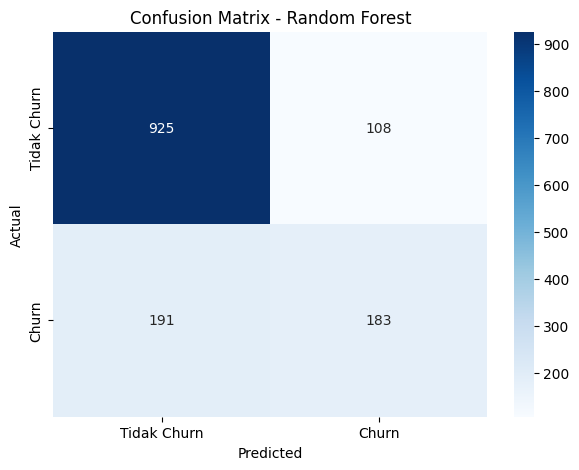

In [34]:
# Membuat Confusion Matrix

cm = confusion_matrix(
    y_te,
    y_pred
)

print("Confusion Matrix:")
print(cm)

# Visualisasi Confusion Matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Tidak Churn",
        "Churn"
    ],
    yticklabels=[
        "Tidak Churn",
        "Churn"
    ]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## ROC Curve

ROC Curve digunakan untuk melihat kemampuan model dalam membedakan pelanggan yang mengalami churn dan tidak mengalami churn pada berbagai threshold probabilitas.

Nilai Area Under Curve atau ROC-AUC yang semakin mendekati 1 menunjukkan kemampuan pemisahan kelas yang semakin baik.


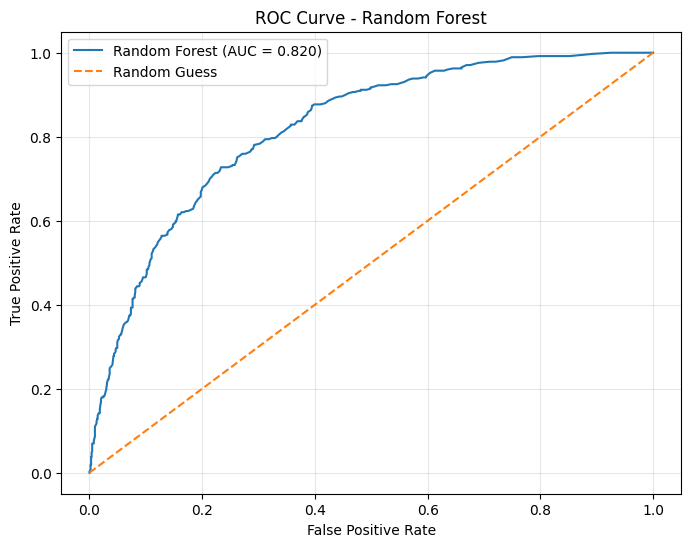

In [35]:
# Menghitung ROC Curve

fpr, tpr, thresholds = roc_curve(
    y_te,
    y_prob
)

# Membuat grafik ROC Curve

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## Langkah 5 — Prediksi Probabilitas

`predict_proba()` menghasilkan probabilitas untuk setiap kelas. Pada praktikum ini probabilitas kelas 1 digunakan sebagai probabilitas pelanggan mengalami churn.

Nilai probabilitas yang semakin mendekati 1 menunjukkan bahwa model semakin yakin pelanggan tersebut termasuk kelompok yang akan mengalami churn.


In [36]:
# Membuat tabel hasil prediksi

result = pd.DataFrame({
    "Actual_Churn": y_te.values,
    "Predicted_Churn": y_pred,
    "Churn_Probability": y_prob
})

display(
    result.head(10)
)

,Actual_Churn,Predicted_Churn,Churn_Probability
0,0,0,0.010000
1,0,1,0.700000
2,0,0,0.016667
3,1,0,0.045793
4,0,0,0.156667
5,1,0,0.226667
6,0,0,0.020000
7,0,0,0.200000
8,1,1,0.703333
9,0,0,0.000000


Probabilitas churn dapat digunakan untuk mengurutkan pelanggan berdasarkan tingkat risiko. Pelanggan dengan probabilitas churn yang lebih tinggi dapat diprioritaskan oleh perusahaan untuk mendapatkan strategi retensi seperti penawaran khusus, komunikasi langsung, atau peningkatan layanan.


In [37]:
# Mengurutkan pelanggan berdasarkan probabilitas churn

high_risk = result.sort_values(
    "Churn_Probability",
    ascending=False
)

print(
    "10 pelanggan dengan probabilitas churn tertinggi:"
)

display(
    high_risk.head(10)
)

10 pelanggan dengan probabilitas churn tertinggi:


,Actual_Churn,Predicted_Churn,Churn_Probability
369,1,1,1.000000
1220,1,1,0.996667
728,0,1,0.996667
107,0,1,0.996667
304,1,1,0.996667
31,1,1,0.990000
261,1,1,0.983333
591,1,1,0.970000
1149,1,1,0.963333
446,0,1,0.960000


## Feature Importance

Random Forest dapat memberikan informasi mengenai tingkat kepentingan setiap fitur dalam proses prediksi. Feature importance digunakan untuk mengetahui fitur mana yang paling banyak berkontribusi terhadap keputusan model.

Hasil ini dapat membantu perusahaan memahami karakteristik pelanggan yang memiliki hubungan paling kuat dengan prediksi churn menurut model.


,Feature,Importance
3,TotalCharges,0.178447
1,tenure,0.165076
2,MonthlyCharges,0.151884
25,Contract_Two year,0.059238
10,InternetService_Fiber optic,0.040405
28,PaymentMethod_Electronic check,0.037501
24,Contract_One year,0.029965
13,OnlineSecurity_Yes,0.028844
4,gender_Male,0.025493
26,PaperlessBilling_Yes,0.023603


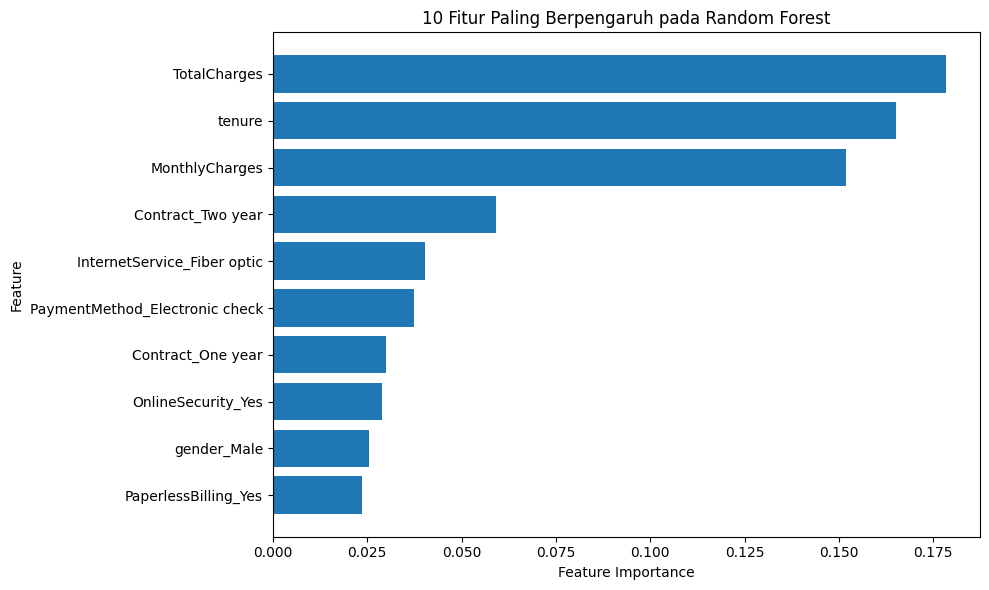

In [39]:
# Menghitung Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(
    feature_importance.head(10)
)


# Mengambil 10 fitur dengan importance tertinggi

top_features = (
    feature_importance
    .head(10)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "10 Fitur Paling Berpengaruh pada Random Forest"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [40]:
# Membuat tabel ringkasan evaluasi

evaluation = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

evaluation["Score"] = evaluation["Score"].round(3)

display(evaluation)

,Metric,Score
0,Accuracy,0.787
1,Precision,0.629
2,Recall,0.489
3,F1-Score,0.550
4,ROC-AUC,0.820


## Analisis Hasil

Berdasarkan hasil evaluasi, Random Forest digunakan untuk memprediksi pelanggan yang berpotensi mengalami churn. Penggunaan `class_weight="balanced"` diterapkan karena distribusi kelas pada dataset tidak seimbang, dengan jumlah pelanggan yang tidak churn lebih banyak dibandingkan pelanggan yang churn.

Precision menunjukkan seberapa tepat prediksi churn yang diberikan model, sedangkan Recall menunjukkan kemampuan model dalam menemukan pelanggan yang benar-benar mengalami churn. Dalam konteks customer churn, Recall menjadi metrik yang penting karena perusahaan ingin mengidentifikasi sebanyak mungkin pelanggan yang berisiko berhenti menggunakan layanan.

ROC-AUC digunakan untuk mengetahui kemampuan model dalam membedakan pelanggan yang churn dan tidak churn berdasarkan probabilitas. Sementara itu, probabilitas yang dihasilkan `predict_proba()` dapat digunakan untuk mengurutkan pelanggan berdasarkan tingkat risiko sehingga perusahaan dapat menentukan prioritas strategi retensi.


# Kesimpulan

Pada praktikum ini telah dipelajari penerapan Random Forest untuk memprediksi customer churn menggunakan dataset Telco Customer Churn yang memiliki distribusi kelas tidak seimbang. Penanganan imbalanced dataset dilakukan dengan menggunakan `class_weight="balanced"` sehingga model memberikan perhatian yang lebih seimbang terhadap kelas minoritas, yaitu pelanggan yang mengalami churn. Berdasarkan hasil evaluasi, model memperoleh Accuracy sebesar [isi nilai], Precision sebesar [isi nilai], Recall sebesar [isi nilai], F1-Score sebesar [isi nilai], dan ROC-AUC sebesar [isi nilai]. Hasil probabilitas churn dari `predict_proba()` dapat digunakan untuk mengidentifikasi pelanggan dengan risiko churn tinggi sehingga perusahaan dapat memprioritaskan strategi retensi.
